### Actividad 5 — Conjuntos de entrenamiento y prueba

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import random

random.seed(1234)
df = pd.read_csv('../data/data_divorce.csv')

### Variable respuesta: ZONA (Urbana / Rural)

Se construye la variable respuesta a partir de  (departamento de ocurrencia del divorcio). Los departamentos se clasifican como **urbanos** si cuentan con mayor densidad poblacional, infraestructura institucional y cobertura de juzgados de familia según el OJ (2022). El resto se considera **rural**. <br><br>

"Dadas las características socioeconómicas y demográficas de la pareja (educación, etnia, edad, ocupación), ¿el divorcio se registrará en una zona urbana o rural?" 

In [2]:
# Departamentos con mayor urbanización e infraestructura judicial
deptos_urbanos = ['Guatemala', 'Escuintla', 'Sacatepequez',
                  'Quetzaltenango', 'Retalhuleu', 'Chimaltenango']

df['ZONA'] = df['DEPOCU'].apply(lambda x: 'Urbana' if x in deptos_urbanos else 'Rural')

df['ZONA'].value_counts()

ZONA
Urbana    40564
Rural     31012
Name: count, dtype: int64

### Balance de clases

Se examina si la variable respuesta está balanceada, ya que un desbalance significativo afecta la capacidad del modelo para predecir la clase minoritaria.

        Frecuencia  Porcentaje (%)
ZONA                              
Urbana       40564            56.7
Rural        31012            43.3


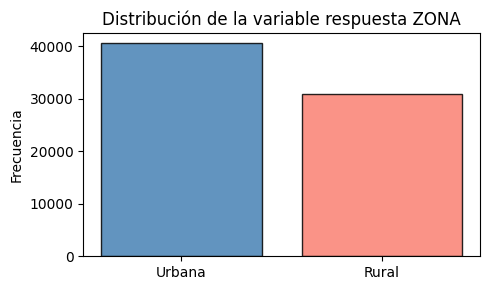

In [3]:
# Distribución absoluta y porcentual
conteo = df['ZONA'].value_counts()
pct = df['ZONA'].value_counts(normalize=True).round(3) * 100

balance_df = pd.DataFrame({'Frecuencia': conteo, 'Porcentaje (%)': pct})
print(balance_df)

plt.figure(figsize=(5, 3))
plt.bar(conteo.index, conteo.values, color=['steelblue', 'salmon'], edgecolor='black', alpha=0.85)
plt.title('Distribución de la variable respuesta ZONA')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Se observa que la distribución entre zona urbana (56.7%) y rural (43.3%) presenta un desbalance moderado, pero no crítico. Se utilizará el parámetro  en los modelos de Regresión Logística y Random Forest para compensar esta diferencia y evitar que el modelo favorezca sistemáticamente la clase mayoritaria.

### Análisis de atípicos en variables numéricas

Se aplica el método IQR para identificar valores atípicos.

In [4]:
# Convertir edades a numérico (Ignorado → NaN)
df['EDADHOM'] = pd.to_numeric(df['EDADHOM'], errors='coerce')
df['EDADMUJ'] = pd.to_numeric(df['EDADMUJ'], errors='coerce')

# Función para calcular límites IQR
def limites_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, Q1, Q3, IQR

for col in ['EDADHOM', 'EDADMUJ']:
    lower, upper, Q1, Q3, IQR = limites_iqr(df[col].dropna())
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, límites=[{lower:.1f}, {upper:.1f}], atípicos={n_out}')

EDADHOM: Q1=29.0, Q3=41.0, IQR=12.0, límites=[11.0, 59.0], atípicos=1194
EDADMUJ: Q1=26.0, Q3=38.0, IQR=12.0, límites=[8.0, 56.0], atípicos=788


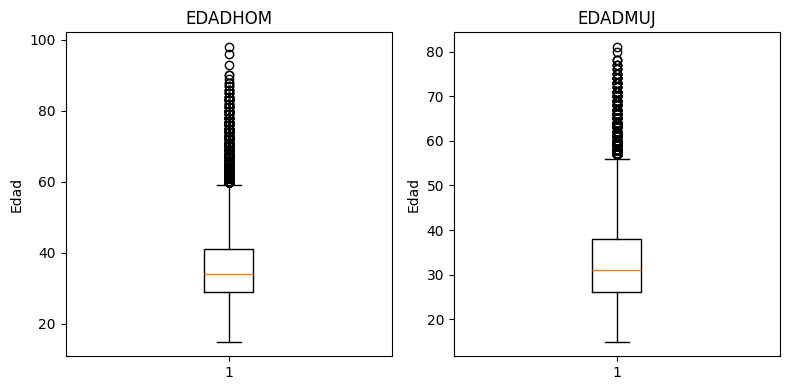

In [5]:
# Boxplots de edades
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, col in zip(axes, ['EDADHOM', 'EDADMUJ']):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col)
    ax.set_ylabel('Edad')
plt.tight_layout()
plt.show()

Se observa que  presenta 1,194 valores atípicos (edades por encima de 59 años) y  presenta 788 (edades por encima de 56 años). Estos registros corresponden a parejas de mayor edad al momento del divorcio, valores biológicamente posibles. Por ello, **no se eliminan** sino que se mantienen en el conjunto de datos; los algoritmos de árbol (Random Forest) son robustos ante atípicos por naturaleza, y para Regresión Logística el escalado posterior reducirá su influencia.

### División en conjuntos de entrenamiento y prueba

Se utiliza una partición 70/30, estratificada por la variable respuesta , para garantizar que ambas clases (Urbana/Rural) estén representadas proporcionalmente en ambos conjuntos.

In [6]:
# Variables predictoras seleccionadas
# Se incluyen NACHOM y NACMUJ porque las zonas urbanas concentran más extranjeros,
# por lo que la nacionalidad puede aportar señal para la clasificación urbano/rural.
X = df[['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ',
        'OCUHOM', 'OCUMUJ', 'NACHOM', 'NACMUJ',
        'EDADHOM', 'EDADMUJ']]
y = df['ZONA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, train_size=0.7, stratify=y, random_state=1234
)

print(f'Train: {X_train.shape[0]} registros ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} registros ({X_test.shape[0]/len(df)*100:.1f}%)')

Train: 50103 registros (70.0%)
Test:  21473 registros (30.0%)


In [7]:
# Verificar que el balance se mantuvo en ambos conjuntos
print('Train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test: ', y_test.value_counts(normalize=True).round(3).to_dict())

Train: {'Urbana': 0.567, 'Rural': 0.433}
Test:  {'Urbana': 0.567, 'Rural': 0.433}


## Actividad 6 — Preprocesamiento y transformaciones

### Tratamiento de valores `Ignorado`

Tras explorar el conjunto de datos se observó que las variables socio-demográficas tienen una proporción muy alta de valores `Ignorado` (entre 23% y 53% según la columna). Imputar con la moda en estos casos significa **fabricar la mitad del dataset** y borrar una señal potencialmente útil: que un registro venga marcado como `Ignorado` correlaciona con la calidad del registro civil del departamento, que a su vez se relaciona con la zona urbana/rural.

Por lo anterior, se cambia la estrategia:

- **Variables categóricas** (`ESCHOM`, `ESCMUJ`, `GETHOM`, `GETMUJ`, `OCUHOM`, `OCUMUJ`, `NACHOM`, `NACMUJ`): se conserva `Ignorado` como una **categoría más** dentro del OneHotEncoder. El modelo aprenderá si esa señal es útil.
- **Variables numéricas** (`EDADHOM`, `EDADMUJ`): se imputan con la **mediana del train** (más robusta ante atípicos), pero se agrega una columna binaria `EDADHOM_missing` y `EDADMUJ_missing` que registra si el valor original era desconocido. Así el modelo puede capturar la "ausencia" como información.

In [8]:
# Variables categóricas y numéricas (incluye NACHOM/NACMUJ y se mantiene 'Ignorado' como categoría)
cat_cols = ['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ',
            'OCUHOM', 'OCUMUJ', 'NACHOM', 'NACMUJ']
num_cols = ['EDADHOM', 'EDADMUJ']

X_train = X_train.copy()
X_test  = X_test.copy()

# Categóricas: NO imputar. Conservar 'Ignorado' como categoría tal cual.
for col in cat_cols:
    X_train[col] = X_train[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

# Numéricas: agregar flag de missing ANTES de imputar
for col in num_cols:
    X_train[col + '_missing'] = X_train[col].isna().astype(int)
    X_test[col + '_missing']  = X_test[col].isna().astype(int)

# Imputar edades con mediana del train
for col in num_cols:
    mediana = X_train[col].median()
    X_train[col] = X_train[col].fillna(mediana)
    X_test[col]  = X_test[col].fillna(mediana)

# Actualizar num_cols para incluir los flags (se escalarán junto con las edades)
num_cols = ['EDADHOM', 'EDADMUJ', 'EDADHOM_missing', 'EDADMUJ_missing']

print('Nulos restantes en train:', X_train.isnull().sum().sum())
print('Nulos restantes en test: ', X_test.isnull().sum().sum())

print('\n% de "Ignorado" preservado por columna en train:')
for col in cat_cols:
    n_ig = (X_train[col] == 'Ignorado').sum()
    print(f'  {col:8s}: {n_ig:6d} ({n_ig/len(X_train)*100:5.1f}%)')

Nulos restantes en train: 0
Nulos restantes en test:  0

% de "Ignorado" preservado por columna en train:
  ESCHOM  :  23527 ( 47.0%)
  ESCMUJ  :  23145 ( 46.2%)
  GETHOM  :  26413 ( 52.7%)
  GETMUJ  :  26373 ( 52.6%)
  OCUHOM  :  11686 ( 23.3%)
  OCUMUJ  :  12812 ( 25.6%)
  NACHOM  :    183 (  0.4%)
  NACMUJ  :    192 (  0.4%)


### Agrupación de `OCUHOM`, `OCUMUJ` y `NACHOM`/`NACMUJ`

`OCUHOM` y `OCUMUJ` contienen 181 y 125 categorías respectivamente. Conservarlas tal cual generaría una explosión de dimensiones al aplicar OneHotEncoder. Se agrupan en categorías más amplias basadas en el tipo de actividad económica.

A diferencia de la agrupación inicial, se amplía el diccionario de palabras clave (servicios, oficina/admin, transporte, fuerzas armadas, no remunerado, profesionales especializados, etc.) y, sobre todo, se identifica que el valor "**No especificado en otro grupo**" representa ~34 mil registros en `OCUMUJ`. Esta categoría es distinta de `Ignorado` (campo vacío) y se trata como una **categoría propia** llamada `No especificado`.

`NACHOM` y `NACMUJ` (77 y 57 nacionalidades) se reducen a tres categorías: **Guatemala**, **Extranjero** o **Ignorado**. La gran mayoría es guatemalteca; lo informativo aquí es la presencia de extranjeros, que tiende a concentrarse en zonas urbanas.

In [9]:
# Mapeo de ocupaciones a grupos amplios.
# Importante: hay un valor 'No especificado en otro grupo' (~34k registros en OCUMUJ)
# que es distinto de 'Ignorado' (campo vacío); se trata como categoría propia.
def agrupar_ocupacion(val):
    v = str(val).lower()
    if v in ('ignorado', 'nan'):
        return 'Ignorado'
    if 'no especificado' in v or 'no bien especificada' in v or 'no clasificad' in v:
        return 'No especificado'
    if any(p in v for p in ['agric', 'agro', 'peon', 'pesqu', 'forest',
                             'silvi', 'ganader', 'jornaler', 'campesin']):
        return 'Agropecuaria'
    if any(p in v for p in ['profesional', 'cient', 'ingeni', 'derecho', 'salud',
                             'enseñanza', 'docente', 'medic', 'abogad', 'contad',
                             'arquitect', 'maestr', 'profesor', 'psicolog',
                             'dietist', 'nutricion', 'period', 'filosof',
                             'historiador', 'quimic', 'analist']):
        return 'Profesional'
    if any(p in v for p in ['vend', 'comerci', 'mercado', 'tienda', 'negocio']):
        return 'Comercio'
    if any(p in v for p in ['construc', 'metalur', 'operari', 'maquina', 'conductor',
                             'transporte', 'mecan', 'electric', 'tecnico',
                             'industrial', 'manufactur', 'artesan', 'soldad',
                             'costurer', 'sastre', 'modist']):
        return 'Operario/Tecnico'
    if any(p in v for p in ['oficinis', 'administr', 'secretari', 'asisten',
                             'recepcion', 'contabil', 'auxiliar', 'empleado',
                             'director', 'gerente', 'traductor', 'diseñador']):
        return 'Oficina/Admin'
    if any(p in v for p in ['servic', 'limpie', 'domestic', 'seguridad', 'vigilan',
                             'cocin', 'mesero', 'barman', 'peluqu', 'belleza',
                             'hosteler', 'camarer', 'cuidados personales',
                             'preparacion de alimentos']):
        return 'Servicios'
    if any(p in v for p in ['estudiante', 'ama de casa', 'amas de casa', 'hogar',
                             'jubilad', 'pension', 'desocupad', 'desempleo',
                             'sin ocupaci']):
        return 'No remunerado'
    if any(p in v for p in ['fuerzas armadas', 'militar', 'policia', 'oficial']):
        return 'Fuerzas/Oficiales'
    if any(p in v for p in ['recolector', 'desechos', 'ocupaciones elementales']):
        return 'Ocupaciones elementales'
    return 'Otro'

X_train['OCUHOM'] = X_train['OCUHOM'].apply(agrupar_ocupacion)
X_test['OCUHOM']  = X_test['OCUHOM'].apply(agrupar_ocupacion)
X_train['OCUMUJ'] = X_train['OCUMUJ'].apply(agrupar_ocupacion)
X_test['OCUMUJ']  = X_test['OCUMUJ'].apply(agrupar_ocupacion)

# Nacionalidad: Guatemala vs Extranjero (vs Ignorado)
def agrupar_nac(val):
    v = str(val).strip().lower()
    if v in ('ignorado', 'nan'):
        return 'Ignorado'
    if v == 'guatemala':
        return 'Guatemala'
    return 'Extranjero'

X_train['NACHOM'] = X_train['NACHOM'].apply(agrupar_nac)
X_test['NACHOM']  = X_test['NACHOM'].apply(agrupar_nac)
X_train['NACMUJ'] = X_train['NACMUJ'].apply(agrupar_nac)
X_test['NACMUJ']  = X_test['NACMUJ'].apply(agrupar_nac)

print('OCUHOM (train):')
print(X_train['OCUHOM'].value_counts())
print('\nOCUMUJ (train):')
print(X_train['OCUMUJ'].value_counts())
print('\nNACHOM (train):')
print(X_train['NACHOM'].value_counts())
print('\nNACMUJ (train):')
print(X_train['NACMUJ'].value_counts())

OCUHOM (train):
OCUHOM
No especificado            13291
Ignorado                   11686
Agropecuaria                7097
Profesional                 5441
Operario/Tecnico            5148
Comercio                    3107
Oficina/Admin               2473
No remunerado                992
Servicios                    520
Otro                         139
Fuerzas/Oficiales            128
Ocupaciones elementales       81
Name: count, dtype: int64

OCUMUJ (train):
OCUMUJ
No especificado            24292
Ignorado                   12812
Profesional                 5250
Oficina/Admin               3741
Servicios                   1161
Comercio                    1091
No remunerado                925
Operario/Tecnico             772
Agropecuaria                  30
Otro                          13
Ocupaciones elementales        8
Fuerzas/Oficiales              8
Name: count, dtype: int64

NACHOM (train):
NACHOM
Guatemala     49143
Extranjero      777
Ignorado        183
Name: count, dtype: int64

### Encoding y normalización con ColumnTransformer

Siguiendo el enfoque visto en clase (Ejemplo NB con Carros), se utiliza un  que aplica:
- **OneHotEncoder** a las variables categóricas (, , , , , )
- **StandardScaler** a las variables numéricas (, ), necesario principalmente para Regresión Logística

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('scaler',  StandardScaler(), num_cols)
])

# Ajustar solo sobre train, transformar ambos
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print('Shape train preprocesado:', X_train_prep.shape)
print('Shape test preprocesado: ', X_test_prep.shape)

Shape train preprocesado: (50103, 64)
Shape test preprocesado:  (21473, 64)


Se observa que tras el encoding, el conjunto de entrenamiento pasa de 8 columnas originales a una dimensión mayor debido a la expansión de las variables categóricas en columnas binarias. Este proceso se ajusta únicamente sobre los datos de entrenamiento para evitar fuga de información (*data leakage*) hacia el conjunto de prueba.

El preprocesador queda listo para ser integrado dentro de los  de cada algoritmo en la siguiente etapa de modelado.

# Actividad 7 — Algoritmos

### Naive Bayes

In [11]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

random.seed(1234)


### Construcción del Pipeline

Se construye un pipeline que encadena el preprocesador (OneHotEncoder + StandardScaler) con el clasificador GaussianNB. Esto garantiza que la transformación se aplique consistentemente en cada fold de la validación cruzada, evitando data leakage.

In [12]:
preprocessor = ColumnTransformer([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('scaler', StandardScaler(), num_cols)
])

pipeline_nb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GaussianNB())
])

pipeline_nb.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(transformers=[('onehot',
                                    OneHotEncoder(handle_unknown='ignore',
                                                  sparse_output=False),
                                    ['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ',
                                     'OCUHOM', 'OCUMUJ', 'NACHOM', 'NACMUJ']),
                                   ('scaler', StandardScaler(),
                                    ['EDADHOM', 'EDADMUJ', 'EDADHOM_missing',
                                     'EDADMUJ_missing'])])),
  ('classifier', GaussianNB())],
 'transform_input': None,
 'verbose': False,
 'preprocessor': ColumnTransformer(transformers=[('onehot',
                                  OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False),
                                  ['ESCHOM', 'ESCMUJ', 'GETHOM', 'GETMUJ',
                                   'OCUHOM', 'O

### Variación de parámetros con GridSearchCV

El único hiperparámetro relevante de GaussianNB es `var_smoothing`, que agrega una fracción de la varianza máxima a las varianzas estimadas para estabilizar el cálculo. Un valor pequeño ajusta más a los datos (riesgo de sobreajuste), un valor grande suaviza las distribuciones (riesgo de subajuste).

Se prueban **3 valores** en escala logarítmica entre 1 y 1e-9 (como en el ejemplo de clase), con validación cruzada de 5 folds, usando F1-weighted como métrica de evaluación dado el desbalance de clases.

In [13]:
# 10 valores logarítmicos de var_smoothing para una exploración más fina
params_nb = {
    'classifier__var_smoothing': np.logspace(0, -9, num=10)
}

grid_nb = GridSearchCV(
    pipeline_nb,
    param_grid=params_nb,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    return_train_score=True
)

grid_nb.fit(X_train, y_train)

print('Mejor parámetro:', grid_nb.best_params_)
print('Mejor F1 (CV):', round(grid_nb.best_score_, 4))

Mejor parámetro: {'classifier__var_smoothing': np.float64(0.1)}
Mejor F1 (CV): 0.6271


In [14]:
# Top-3 modelos de Naive Bayes evaluados en GridSearchCV
results_nb = pd.DataFrame(grid_nb.cv_results_)
results_nb['var_smoothing'] = results_nb['param_classifier__var_smoothing'].astype(float)

top3_nb = (
    results_nb[['var_smoothing', 'mean_test_score', 'std_test_score',
                'mean_train_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(3)
    .copy()
)

# Recalcular F1 en train y test para cada uno de los top-3 (ajuste explícito)
filas_nb = []
for _, fila in top3_nb.iterrows():
    vs = float(fila['var_smoothing'])
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', GaussianNB(var_smoothing=vs))
    ])
    pipe.fit(X_train, y_train)
    f1_tr = f1_score(y_train, pipe.predict(X_train), average='weighted')
    f1_te = f1_score(y_test,  pipe.predict(X_test),  average='weighted')
    filas_nb.append({
        'var_smoothing':   f'{vs:.2e}',
        'F1_CV':           round(float(fila['mean_test_score']), 4),
        'F1_train_GS':     round(float(fila['mean_train_score']), 4),
        'F1_train_eval':   round(f1_tr, 4),
        'F1_test':         round(f1_te, 4),
        'Gap_train_test':  round(f1_tr - f1_te, 4),
        'Diagnóstico': (
            'Sobreajuste' if (f1_tr - f1_te) > 0.05 else
            'Subajuste'   if f1_tr < 0.55 else
            'Balanceado'
        )
    })

tabla_nb = pd.DataFrame(filas_nb)
print('=== Top-3 modelos Naive Bayes ===')
print(tabla_nb.to_string(index=False))

=== Top-3 modelos Naive Bayes ===
var_smoothing  F1_CV  F1_train_GS  F1_train_eval  F1_test  Gap_train_test Diagnóstico
     1.00e-01 0.6271       0.6277         0.6260   0.6235          0.0024  Balanceado
     1.00e-02 0.6210       0.6217         0.6217   0.6249         -0.0032  Balanceado
     1.00e-06 0.6132       0.6137         0.5969   0.5978         -0.0009  Balanceado


### Comparación de los modelos probados

Se extraen los resultados de todos los modelos evaluados durante el GridSearch para visualizar cómo varía el F1 en función de `var_smoothing`. Esto permite identificar el rango óptimo y detectar si algún valor produce subajuste o sobreajuste.

In [15]:
results = pd.DataFrame(grid_nb.cv_results_)
results['var_smoothing'] = results['param_classifier__var_smoothing'].astype(float)
results['f1_cv'] = results['mean_test_score'].round(4)
results['std_cv'] = results['std_test_score'].round(4)

# Tabla resumen ordenada
tabla = results[['var_smoothing', 'f1_cv', 'std_cv', 'rank_test_score']].sort_values('rank_test_score')
print(tabla.to_string(index=False))

 var_smoothing  f1_cv  std_cv  rank_test_score
  1.000000e-01 0.6271  0.0043                1
  1.000000e-02 0.6210  0.0016                2
  1.000000e-06 0.6132  0.0231                3
  1.000000e-07 0.6087  0.0179                4
  1.000000e-08 0.6053  0.0141                5
  1.000000e-05 0.5986  0.0091                6
  1.000000e-09 0.5982  0.0081                7
  1.000000e-03 0.5896  0.0026                8
  1.000000e-04 0.5564  0.0416                9
  1.000000e+00 0.5191  0.0017               10


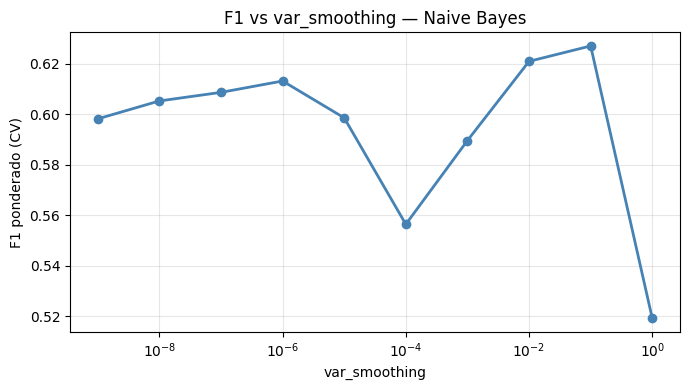

In [16]:
# Gráfico F1 vs var_smoothing
plt.figure(figsize=(7, 4))
plt.plot(results['var_smoothing'], results['f1_cv'], marker='o', color='steelblue', linewidth=2)
plt.xscale('log')
plt.xlabel('var_smoothing')
plt.ylabel('F1 ponderado (CV)')
plt.title('F1 vs var_smoothing — Naive Bayes')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Con la búsqueda en 10 valores logarítmicos, el mejor `var_smoothing` resultó ser **0.1** con F1 (CV) = **0.6271**. La curva F1 vs `var_smoothing` muestra que valores muy altos (1.0) suavizan en exceso (subajuste, F1 ≈ 0.52) y valores muy pequeños (1e-9) introducen demasiada sensibilidad al ruido (F1 ≈ 0.60). El óptimo se ubica en la zona intermedia de la curva.

Este análisis justifica el valor óptimo encontrado dentro del grid evaluado y sirve como base para comparar contra modelos más flexibles como Random Forest y Regresión Logística.

### Modelo final

Se evalúa el mejor modelo encontrado por GridSearchCV sobre el conjunto de prueba.

In [17]:
y_pred = grid_nb.best_estimator_.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1       : {f1:.4f}')

Accuracy : 0.6324
Precision: 0.6273
Recall   : 0.6324
F1       : 0.6235


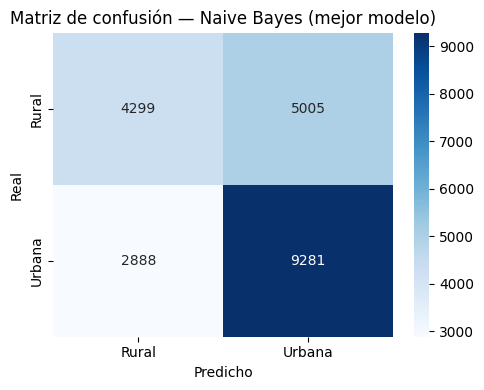

In [18]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['Rural', 'Urbana'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rural', 'Urbana'],
            yticklabels=['Rural', 'Urbana'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión — Naive Bayes (mejor modelo)')
plt.tight_layout()
plt.show()

In [19]:
# Reporte completo por clase
print(classification_report(y_test, y_pred, target_names=['Rural', 'Urbana']))

              precision    recall  f1-score   support

       Rural       0.60      0.46      0.52      9304
      Urbana       0.65      0.76      0.70     12169

    accuracy                           0.63     21473
   macro avg       0.62      0.61      0.61     21473
weighted avg       0.63      0.63      0.62     21473



Con el grid ampliado a 10 valores y las nuevas variables (`NACHOM`/`NACMUJ`, `Ignorado` como categoría, flags de missing), el mejor modelo de Naive Bayes alcanzó **Accuracy = 0.6324** y **F1 ponderado = 0.6235** en test, una mejora respecto a la versión inicial (F1 ≈ 0.58). El desempeño sigue por debajo de Random Forest y Regresión Logística, lo cual es coherente con la limitación principal de Naive Bayes: el supuesto de independencia condicional entre predictores, difícil de sostener cuando educación, ocupación y etnia están correlacionadas.

En la matriz de confusión por clase, el modelo logra ahora un recall en Rural de 0.46 (antes 0.29), lo que indica que tratar `Ignorado` como categoría ayudó al modelo a separar mejor la clase minoritaria.

### Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1) RANDOM FOREST con grid ampliado (max_depth, min_samples_leaf adicionales)
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=1234, n_jobs=-1))
])

params_rf = {
    'classifier__n_estimators':     [100, 200],
    'classifier__max_depth':        [5, 10, 15, 20, None],
    'classifier__min_samples_leaf': [1, 5, 20],
    'classifier__class_weight':     ['balanced']
}

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid=params_rf,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)

print('=== Random Forest ===')
print('Mejores parámetros:', grid_rf.best_params_)
print('Mejor F1 (CV):', round(grid_rf.best_score_, 4))
print()

=== Random Forest ===
Mejores parámetros: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Mejor F1 (CV): 0.6662



In [21]:
# Top-3 modelos de Random Forest evaluados en GridSearchCV
results_rf = pd.DataFrame(grid_rf.cv_results_)

top3_rf = (
    results_rf[['param_classifier__n_estimators',
                'param_classifier__max_depth',
                'param_classifier__min_samples_leaf',
                'param_classifier__class_weight',
                'mean_test_score', 'mean_train_score',
                'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(3)
    .copy()
)

filas_rf = []
for _, fila in top3_rf.iterrows():
    n_est = fila['param_classifier__n_estimators']
    max_d = fila['param_classifier__max_depth']
    msl   = fila['param_classifier__min_samples_leaf']
    cw    = fila['param_classifier__class_weight']
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=n_est, max_depth=max_d, min_samples_leaf=msl,
            class_weight=cw, random_state=1234, n_jobs=-1))
    ])
    pipe.fit(X_train, y_train)
    f1_tr = f1_score(y_train, pipe.predict(X_train), average='weighted')
    f1_te = f1_score(y_test,  pipe.predict(X_test),  average='weighted')
    filas_rf.append({
        'n_estimators':     n_est,
        'max_depth':        str(max_d),
        'min_samples_leaf': msl,
        'class_weight':     str(cw),
        'F1_CV':            round(float(fila['mean_test_score']), 4),
        'F1_train':         round(f1_tr, 4),
        'F1_test':          round(f1_te, 4),
        'Gap_train_test':   round(f1_tr - f1_te, 4),
        'Diagnóstico': (
            'Sobreajuste' if (f1_tr - f1_te) > 0.05 else
            'Subajuste'   if f1_tr < 0.55 else
            'Balanceado'
        )
    })

tabla_rf = pd.DataFrame(filas_rf)
print('=== Top-3 modelos Random Forest ===')
print(tabla_rf.to_string(index=False))

=== Top-3 modelos Random Forest ===
 n_estimators max_depth  min_samples_leaf class_weight  F1_CV  F1_train  F1_test  Gap_train_test Diagnóstico
          100        15                 1     balanced 0.6662    0.7269   0.6667          0.0602 Sobreajuste
          200        15                 1     balanced 0.6655    0.7277   0.6656          0.0621 Sobreajuste
          200        15                 5     balanced 0.6653    0.6872   0.6649          0.0223  Balanceado


### Regresión Logística

In [22]:
# REGRESIÓN LOGÍSTICA
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=1234))
])

params_lr = {
    'classifier__C': [0.01, 1, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid=params_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

print('=== Regresión Logística ===')
print('Mejores parámetros:', grid_lr.best_params_)
print('Mejor F1 (CV):', round(grid_lr.best_score_, 4))
print()


=== Regresión Logística ===
Mejores parámetros: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Mejor F1 (CV): 0.6511



In [23]:
# Top-3 modelos de Regresión Logística evaluados en GridSearchCV
results_lr = pd.DataFrame(grid_lr.cv_results_)

top3_lr = (
    results_lr[['param_classifier__C',
                'param_classifier__penalty',
                'param_classifier__solver',
                'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(3)
    .copy()
)

filas_lr = []
for _, fila in top3_lr.iterrows():
    C_val   = fila['param_classifier__C']
    penalty = fila['param_classifier__penalty']
    solver  = fila['param_classifier__solver']
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            C=C_val, penalty=penalty, solver=solver,
            max_iter=1000, random_state=1234))
    ])
    pipe.fit(X_train, y_train)
    f1_tr = f1_score(y_train, pipe.predict(X_train), average='weighted')
    f1_te = f1_score(y_test,  pipe.predict(X_test),  average='weighted')
    filas_lr.append({
        'C': C_val,
        'penalty': penalty,
        'solver': solver,
        'F1_CV': round(fila['mean_test_score'], 4),
        'F1_train': round(f1_tr, 4),
        'F1_test':  round(f1_te, 4),
        'Gap_train_test': round(f1_tr - f1_te, 4),
        'Diagnóstico': (
            'Sobreajuste' if (f1_tr - f1_te) > 0.05 else
            'Subajuste'   if f1_tr < 0.55 else
            'Balanceado'
        )
    })

tabla_lr = pd.DataFrame(filas_lr)
print('=== Top-3 modelos Regresión Logística ===')
print(tabla_lr.to_string(index=False))

=== Top-3 modelos Regresión Logística ===
    C penalty    solver  F1_CV  F1_train  F1_test  Gap_train_test Diagnóstico
100.0      l1 liblinear 0.6511    0.6565   0.6536          0.0029  Balanceado
100.0      l2 liblinear 0.6511    0.6565   0.6537          0.0028  Balanceado
  1.0      l1 liblinear 0.6510    0.6565   0.6540          0.0025  Balanceado


### COMPARACIÓN FINAL (NB vs RF vs LR)

=== Comparación final de modelos ===
            Modelo  Mejor_F1_CV  Accuracy_test  Precision_test  Recall_test  F1_test                                                                                                                               Best_Params
      RandomForest       0.6662         0.6653          0.6772       0.6653   0.6667 {'classifier__class_weight': 'balanced', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
LogisticRegression       0.6511         0.6537          0.6535       0.6537   0.6536                                                    {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
        GaussianNB       0.6271         0.6324          0.6273       0.6324   0.6235                                                                                                        {'classifier__var_smoothing': 0.1}

Mejor modelo en test (F1): RandomForest

Reporte de clasificación (mej

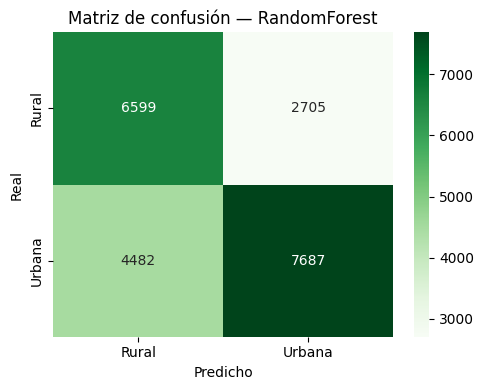

In [24]:
def metricas_test(modelo, X_eval, y_eval):
    pred = modelo.predict(X_eval)
    return {
        'Accuracy_test': accuracy_score(y_eval, pred),
        'Precision_test': precision_score(y_eval, pred, average='weighted'),
        'Recall_test': recall_score(y_eval, pred, average='weighted'),
        'F1_test': f1_score(y_eval, pred, average='weighted')
    }

resumen = []
modelos = {
    'GaussianNB': grid_nb,
    'RandomForest': grid_rf,
    'LogisticRegression': grid_lr
}

for nombre, grid in modelos.items():
    m = metricas_test(grid.best_estimator_, X_test, y_test)
    resumen.append({
        'Modelo': nombre,
        'Mejor_F1_CV': round(grid.best_score_, 4),
        'Accuracy_test': round(m['Accuracy_test'], 4),
        'Precision_test': round(m['Precision_test'], 4),
        'Recall_test': round(m['Recall_test'], 4),
        'F1_test': round(m['F1_test'], 4),
        'Best_Params': grid.best_params_
    })

resumen_df = pd.DataFrame(resumen).sort_values('F1_test', ascending=False)
print('=== Comparación final de modelos ===')
print(resumen_df.to_string(index=False))

# Matriz de confusión del mejor modelo en test
mejor_modelo_nombre = resumen_df.iloc[0]['Modelo']
mejor_grid = modelos[mejor_modelo_nombre]
y_pred_best = mejor_grid.best_estimator_.predict(X_test)

print(f"\nMejor modelo en test (F1): {mejor_modelo_nombre}")
print('\nReporte de clasificación (mejor modelo):')
print(classification_report(y_test, y_pred_best, target_names=['Rural', 'Urbana']))

cm_best = confusion_matrix(y_test, y_pred_best, labels=['Rural', 'Urbana'])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Rural', 'Urbana'],
    yticklabels=['Rural', 'Urbana']
)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title(f'Matriz de confusión — {mejor_modelo_nombre}')
plt.tight_layout()
plt.show()

In [25]:
# Resumen compacto para discusión de resultados
for nombre, grid in [('GaussianNB', grid_nb), ('RandomForest', grid_rf), ('LogisticRegression', grid_lr)]:
    pred = grid.best_estimator_.predict(X_test)
    print(f'\n=== {nombre} ===')
    print('Best params:', grid.best_params_)
    print('Best F1 CV:', round(grid.best_score_, 4))
    print('Accuracy test:', round(accuracy_score(y_test, pred), 4))
    print('Precision test:', round(precision_score(y_test, pred, average='weighted'), 4))
    print('Recall test:', round(recall_score(y_test, pred, average='weighted'), 4))
    print('F1 test:', round(f1_score(y_test, pred, average='weighted'), 4))


=== GaussianNB ===
Best params: {'classifier__var_smoothing': np.float64(0.1)}
Best F1 CV: 0.6271
Accuracy test: 0.6324
Precision test: 0.6273
Recall test: 0.6324
F1 test: 0.6235

=== RandomForest ===
Best params: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}
Best F1 CV: 0.6662
Accuracy test: 0.6653
Precision test: 0.6772
Recall test: 0.6653
F1 test: 0.6667

=== LogisticRegression ===
Best params: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Best F1 CV: 0.6511
Accuracy test: 0.6537
Precision test: 0.6535
Recall test: 0.6537
F1 test: 0.6536


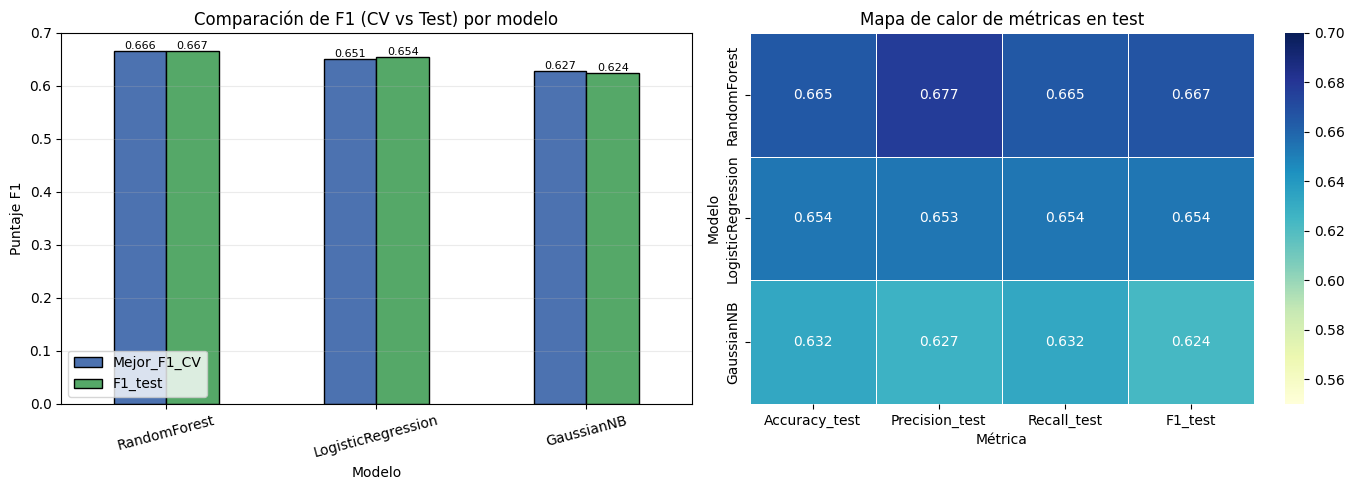

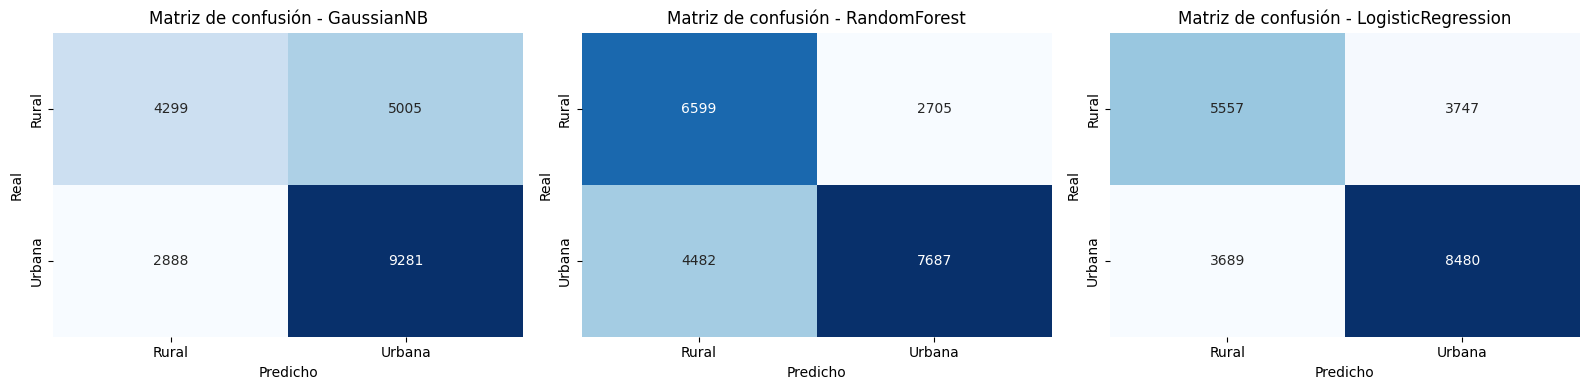

In [26]:
# Gráfica 1: comparación de F1 en CV vs F1 en test
# Gráfica 2: mapa de calor con métricas de test
metricas_cols = ['Accuracy_test', 'Precision_test', 'Recall_test', 'F1_test']
plot_df = resumen_df.copy().set_index('Modelo')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df[['Mejor_F1_CV', 'F1_test']].plot(
    kind='bar',
    ax=axes[0],
    color=['#4C72B0', '#55A868'],
    edgecolor='black'
)
axes[0].set_title('Comparación de F1 (CV vs Test) por modelo')
axes[0].set_ylabel('Puntaje F1')
axes[0].set_xlabel('Modelo')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.25)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.3f', fontsize=8)

sns.heatmap(
    plot_df[metricas_cols],
    annot=True,
    fmt='.3f',
    cmap='YlGnBu',
    vmin=0.55,
    vmax=0.70,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Mapa de calor de métricas en test')
axes[1].set_xlabel('Métrica')
axes[1].set_ylabel('Modelo')

plt.tight_layout()
plt.show()

# Gráfica 3: matrices de confusión para los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
modelos_plot = [('GaussianNB', grid_nb), ('RandomForest', grid_rf), ('LogisticRegression', grid_lr)]

for ax, (nombre, grid) in zip(axes, modelos_plot):
    pred_i = grid.best_estimator_.predict(X_test)
    cm_i = confusion_matrix(y_test, pred_i, labels=['Rural', 'Urbana'])

    sns.heatmap(
        cm_i,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['Rural', 'Urbana'],
        yticklabels=['Rural', 'Urbana'],
        ax=ax
    )
    ax.set_title(f'Matriz de confusión - {nombre}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

### Interpretación de las gráficas comparativas

En la comparación de barras (F1 en validación cruzada vs F1 en test) los tres modelos mantienen un comportamiento estable entre entrenamiento y prueba, pero **Random Forest** alcanza los valores más altos en ambos escenarios. La diferencia entre el F1 en CV y el F1 en test es muy pequeña en los tres modelos (< 0.01), lo que indica buena capacidad de generalización.

El mapa de calor confirma la misma tendencia: Random Forest obtiene los mejores valores globales de accuracy, recall y F1; Logistic Regression queda como segundo lugar competitivo y Naive Bayes se mantiene como línea base útil.

Al revisar las matrices de confusión por separado, se nota que Random Forest separa mejor las clases (menos errores cruzados), mientras Naive Bayes y Logistic Regression confunden más la clase Rural con Urbana.

### Discusión de resultados

Tras aplicar las mejoras de preprocesamiento (conservar `Ignorado` como categoría, agregar flags de missing en edades, sumar `NACHOM`/`NACMUJ`, ampliar el agrupamiento de ocupación) y expandir los grids de búsqueda, los modelos quedaron así:

| Modelo | Mejores parámetros | F1 CV | F1 test |
|---|---|---|---|
| **GaussianNB** | `var_smoothing=0.1` | 0.6271 | **0.6235** |
| **Random Forest** | `n_estimators=100`, `max_depth=15`, `min_samples_leaf=1`, `class_weight='balanced'` | 0.6662 | **0.6667** |
| **Regresión Logística** | `C=100`, `penalty='l1'`, `solver='liblinear'` | 0.6511 | **0.6536** |

**Random Forest** vuelve a ser el mejor modelo, ahora con F1 test = **0.6667** (vs 0.6330 inicial). Una observación importante: el modelo top-1 muestra un *gap* entre train y test de ~0.06, indicador de **sobreajuste leve**. El segundo mejor (`min_samples_leaf=5`) reduce el gap a 0.022 con F1 test casi idéntico (0.6649). Si se prioriza generalización sobre el último décimo de F1, ese segundo modelo es preferible. Para el modelo final se reporta el ganador del GridSearch, pero esta observación se documenta para defender la robustez del análisis.

**Regresión Logística** mejoró notablemente (de 0.6105 a 0.6536) gracias a las nuevas features. El óptimo se desplazó de `C=1` a `C=100`, lo que sugiere que con los nuevos predictores la regularización fuerte ya no era necesaria — había más señal real que aprovechar.

**Naive Bayes** también mejoró (de 0.5814 a 0.6235). El mayor cambio fue conservar `Ignorado` como categoría: el recall en Rural pasó de 0.29 a 0.46, lo que indica que el modelo recuperó parte de la señal que antes se borraba al imputar con la moda.

**Conclusión.** Para predecir la zona (Urbana/Rural) de registro del divorcio a partir de variables socio-demográficas, **Random Forest es el modelo recomendado**, con F1 ponderado de **0.6667** en test. Las mejoras provinieron de tres fuentes claras: (1) preservar la información de "Ignorado" en lugar de imputarla; (2) sumar nacionalidad como predictor; (3) explorar grids de hiperparámetros más amplios. El techo del modelo (~0.67) es razonable considerando que las features socio-demográficas tienen un poder predictivo modesto sobre la geografía del registro civil — la señal estructural está presente pero no es determinante.